In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import json

from openai import AzureOpenAI
import nest_asyncio
nest_asyncio.apply()

## OpenAI Agent

### Define model

In [ ]:
import os

# define model arguments
deployment_name = 'gpt-4o-mini'  # This should match your Azure deployment name
chunk_size = 32 # number of prompts per batch (controls the progress bar)

agent = AzureOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    api_version="2024-02-15-preview",
    azure_deployment=deployment_name
)

### Simple usage: question & answer

In [7]:
# 1 system prompt, 1 user prompt
system_prompt = "You are a calculator"
user_prompt = "What is 200 + 152?"

response = agent.chat.completions.create(
    model=deployment_name,  # Use the deployment name from earlier
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ],
    temperature=0.0
)

# Extract the response content
response_content = response.choices[0].message.content
print(response_content)

200 + 152 equals 352.


In [9]:
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

system_prompt = "You are a robot that returns executable codes in Python with no explanation."
user_prompt = "Write a recursive function that calculates fibonacci numbers."

# Create messages and get response
response = agent.chat.completions.create(
    model=deployment_name,  # Use the deployment name from earlier
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ],
    temperature=0.0
)

# Extract and display the response
response_content = response.choices[0].message.content
printmd(response_content)

```python
def fibonacci(n):
    if n <= 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)

# Example usage:
# print(fibonacci(10))  # Output: 55
```

### Multiple user prompts

In [10]:
system_prompt = "You are a music critic. Answer music related questions in a concise and informative manner in at most 3 bulletpoints in json format."
user_prompts = [
    "What are some classical influences seen in Taylor Swift's music?",
    "What are some hip-hop influences seen in modern kpop?"
]

responses = []

for user_prompt in user_prompts:
    response = agent.chat.completions.create(
        model=deployment_name,  # Use the deployment name from earlier
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=1.0,
        response_format={"type": "json_object"}
    )

    # Extract the response content
    response_content = response.choices[0].message.content
    responses.append(response_content)

# Display all responses
for r in responses:
    printmd(r)

{
  "classical_influences": [
    "Swift incorporates intricate storytelling and thematic development in her lyrics, reminiscent of classical compositions that often tell a story or explore deep emotional themes.",
    "Orchestral arrangements and string sections are present in many of her songs, particularly in albums like 'Folklore' and 'Evermore', drawing upon classical instrumentation for a richer sound.",
    "Harmonic progressions and melodic structures in her music exhibit classical elements, showing influences from both classical pop and the great composers in terms of emotional expression and musicality."
  ]
}

{
  "hipHopInfluencesInKpop": [
    "Use of rhythmic vocal delivery and rap sections in songs, incorporating elements from both hip-hop and traditional K-pop melodies.",
    "Inclusion of hip-hop beats and production styles, such as trap and bass-heavy tracks, which contribute to a more urban sound.",
    "Fashion and performance aesthetics that draw from hip-hop culture, including streetwear, confident choreography, and collaborations with hip-hop artists."
  ]
}

### Input and output in dataframes

In [11]:
np.random.seed(0)
df = pd.DataFrame(
    {'Number 1': np.random.randint(0,100, size=10),
     'Number 2': np.random.randint(0,100, size=10)}
)
df

,Number 1,Number 2
0,44,70
1,47,88
2,64,88
3,67,12
4,67,58
5,9,65
6,83,39
7,21,87
8,36,46
9,87,88


In [12]:
import pandas as pd

# system prompt, user prompt should be string with placeholders for column names to be filled in
system_prompt = "You are a calculator. Return a single number for your answer without any additional information."
user_prompt = "Add the following numbers: {Number 1} and {Number 2}."

def get_llm_response(row):
    # Format the user prompt with row data
    formatted_user_prompt = user_prompt.format(**row.to_dict())

    # Get response from Azure OpenAI
    response = agent.chat.completions.create(
        model=deployment_name,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": formatted_user_prompt}
        ],
        temperature=0.0
    )

    return response.choices[0].message.content

# Apply the function to each row
df['llm_response'] = df.apply(get_llm_response, axis=1)
df

,Number 1,Number 2,llm_response
0,44,70,114
1,47,88,135
2,64,88,152
3,67,12,79
4,67,58,125
5,9,65,74
6,83,39,122
7,21,87,108
8,36,46,82
9,87,88,175


In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

#### One image per text prompt

In [11]:
# download example photos of pets
img_folder = '../data/imgs/animals'
os.makedirs(img_folder, exist_ok=True)

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9b/Gustav_chocolate.jpg/336px-Gustav_chocolate.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Orange_tabby_cat_sitting_on_fallen_leaves-Hisashi-01A.jpg/360px-Orange_tabby_cat_sitting_on_fallen_leaves-Hisashi-01A.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/9/99/Brooks_Chase_Ranger_of_Jolly_Dogs_Jack_Russell.jpg/640px-Brooks_Chase_Ranger_of_Jolly_Dogs_Jack_Russell.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/7/7a/Huskiesatrest.jpg/640px-Huskiesatrest.jpg",
]

for i, url in enumerate(urls):
    urllib.request.urlretrieve(url, os.path.join(img_folder, f'img_{i}.jpg'))

In [12]:
system_prompt = """You are an animals expert. Identify what animal it is and the species of the animal. Return your answer strictly in the following format: 
Animal: X; Species: Y
"""
text_prompt = "Here is an animal:"
img_paths = [os.path.join(img_folder, img) for img in os.listdir(img_folder)]

# generate multimodal user_prompts
user_prompts = agent.format_img_prompts(text_prompts=text_prompt, image_paths=img_paths)

# run analysis
agent.set_chunk_size(1) # pass in images one by one - image prompts take longer so this makes progress bar clearer
prompts = agent.generate_prompts(system_prompt, user_prompts)
responses = agent.get_responses(prompts, temperature=0.0)

Running cost $0.0050: 100%|██████████| 4/4 [00:04<00:00,  1.23s/chunk]


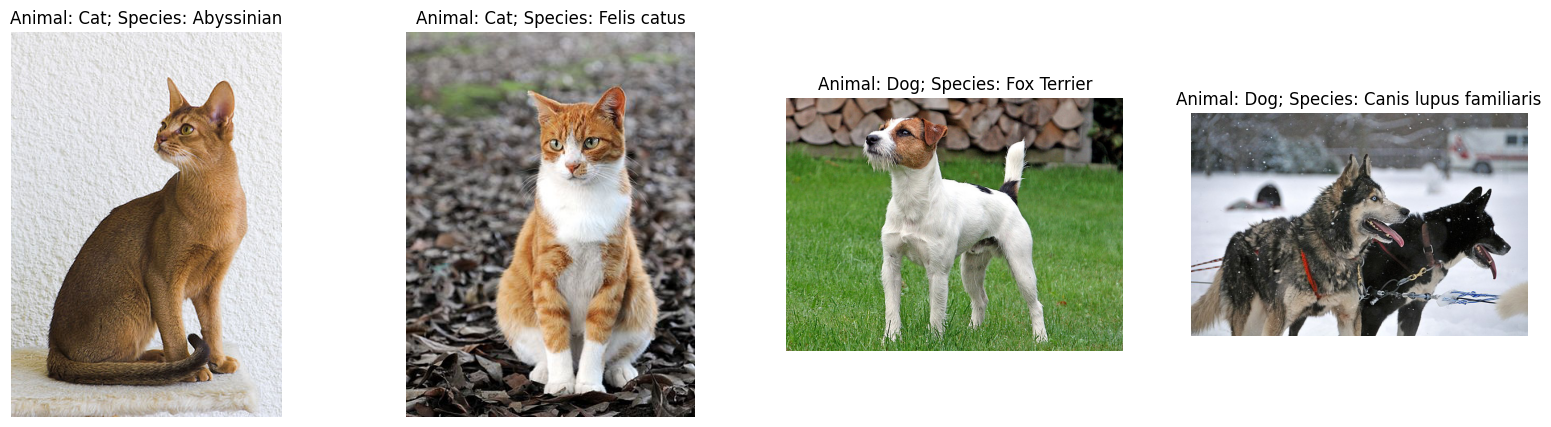

In [13]:
fig, ax = plt.subplots(1,4,figsize=(20,5))
imgs = [Image.open(img_paths[i]) for i in range(len(img_paths))]
for i in range(len(img_paths)):
    ax[i].imshow(imgs[i])
    ax[i].set_title(responses[i])
    ax[i].axis('off')

#### Multiple images per text prompt

In [14]:
system_prompt = "you are an animals expert."
text_prompt = "Picture 1-4 which ones are cats? What species are they?"
img_paths_list = [img_paths]

# generate multimodal user_prompts
user_prompts = agent.format_img_prompts(text_prompts=text_prompt, image_paths=img_paths_list)

# run analysis
prompts = agent.generate_prompts(system_prompt, user_prompts)
responses = agent.get_responses(prompts, temperature=0.0)

Running cost $0.0071: 100%|██████████| 1/1 [00:04<00:00,  4.79s/chunk]


In [15]:
print(responses[0])

In the images you provided:

1. **Image 1**: This is a cat. It appears to be an Abyssinian breed.
2. **Image 2**: This is also a cat. It looks like a domestic shorthair, possibly a mixed breed.
3. **Image 3**: This is a dog, specifically a Jack Russell Terrier.
4. **Image 4**: These are also dogs, likely Siberian Huskies.

So, the first two images are cats, while the last two are dogs.


### Embeddings

In [16]:
# generate a list of texts to show off how cosine similarity works
text_list = [
    "USA",
    "America",
    "United States",
    "George Washington",
    "Washington DC",
    "The White House",
    "California",
    "Hollywood",
    "Silicon Valley",
    "New York City",
    "The Statue of Liberty",
    "The Empire State Building",
    "Finance",
    "Private Equity",
]

embedded_text_list = agent.embeddings(text_list)
embedded_text = agent.embeddings("Advent International")

assert len(embedded_text) == 3072
assert len(embedded_text_list) == len(text_list)

In [17]:
cosine_similarities = agent.cosine_similarity(embedded_text, embedded_text_list)
sorted_text_list = [text for _, text in sorted(zip(cosine_similarities, text_list), reverse=True)]
sorted_text_list

['Private Equity',
 'Finance',
 'Silicon Valley',
 'USA',
 'Washington DC',
 'America',
 'United States',
 'Hollywood',
 'New York City',
 'George Washington',
 'The Empire State Building',
 'The White House',
 'California',
 'The Statue of Liberty']

### Batching

Recommended for more than 25000 requests to gpt-4o-mini and 15000 requests to gpt-4o

#### Define Batch Model

In [2]:
from pyvent.tools import SaveTool
from pyvent.constants import ROOT_DIR
import os

model = 'gpt-4o-mini-batch'
# model = 'gpt-4o-batch'

saver = SaveTool(
    data_path=os.path.join(ROOT_DIR, "data", "openai_test"),
    input_path="input",
    output_path="output"
)

agent = OpenAIAgent(model=model, saver=saver)

In [5]:
# Define a large number of prompts to test batching
system_prompt = "You are a helpful assistant."
user_prompts = [f"What is {i} + {i}" for i in range(1000)]

# Generate prompts
prompts = agent.generate_prompts(system_prompt, user_prompts)

In [6]:
# test the amount of tokens you are about to send in
agent.get_predicted_total_cost(prompts,estimated_output_tokens=1)

# test the amount of tokens using an example phrase
agent.get_predicted_total_cost(prompts,average_output_phrase='500 + 500 equals 1000.')


        Total prompt tokens: 24000
        Estimated output tokens: 1000
        Prompt token cost: $0.0018
        Estimated completion token cost: $0.0003
        Estimated Total cost: $0.0021
        

        Total prompt tokens: 24000
        Estimated output tokens: 9000
        Prompt token cost: $0.0018
        Estimated completion token cost: $0.0027
        Estimated Total cost: $0.0045
        


In [ ]:
# Run the prompts in batch mode
responses = agent.get_responses(prompts, batch=True, temperature=0.0)

Running batch with 1000 prompts
Batch files saved to ['C:\\Users\\trichardson\\Github\\pyvent\\data\\openai_test\\input\\prompt_batch_0.jsonl']
Submitting batches
2024-11-14 17:06:16.616648 File Id: file-02a93fefe72b417bbbb2f96b6846b9e5,  Status: pending
2024-11-14 17:06:37.190383 File Id: file-02a93fefe72b417bbbb2f96b6846b9e5,  Status: processed
Files uploaded with ids: ['file-02a93fefe72b417bbbb2f96b6846b9e5']
Batches submitted with ids: ['batch_09784fb9-1ca0-4640-98e9-3763d61cd9b9']
Retrieving batches
2024-11-14 17:06:58.692331 Batch Id: batch_09784fb9-1ca0-4640-98e9-3763d61cd9b9,  Status: validating


In [3]:
# run with df
df = pd.DataFrame(
    {'Number 1': np.random.randint(0,100, size=100),
     'Number 2': np.random.randint(0,100, size=100)}
)
system_prompt = "You are a calculator. Return a single number for your answer without any additional information."
user_prompt = "Add the following numbers: {Number 1} and {Number 2}. And return the result in json format with the key value."

df = agent.format_df_prompts(df, system_prompt, user_prompt)
df = agent.run_df_prompts(df, batch=True, temperature=0.0, response_format={'type':'json_object'})

Running batch with 100 prompts
Batch files saved to ['C:\\Users\\trichardson\\Github\\pyvent\\data\\openai_test\\input\\prompt_batch_0.jsonl']
Submitting batches
2024-11-14 16:51:17.069475 File Id: file-ca8fb04901e546c5be2463402980744a,  Status: pending
2024-11-14 16:51:37.586585 File Id: file-ca8fb04901e546c5be2463402980744a,  Status: processed
Files uploaded with ids: ['file-ca8fb04901e546c5be2463402980744a']
Batches submitted with ids: ['batch_dea27fe9-e533-4202-b82c-c83e00823d08']
Retrieving batches
2024-11-14 16:51:58.908921 Batch Id: batch_dea27fe9-e533-4202-b82c-c83e00823d08,  Status: validating
2024-11-14 16:53:29.447596 Batch Id: batch_dea27fe9-e533-4202-b82c-c83e00823d08,  Status: validating
2024-11-14 16:54:59.973345 Batch Id: batch_dea27fe9-e533-4202-b82c-c83e00823d08,  Status: in_progress
2024-11-14 16:56:30.525735 Batch Id: batch_dea27fe9-e533-4202-b82c-c83e00823d08,  Status: in_progress
2024-11-14 16:58:01.136462 Batch Id: batch_dea27fe9-e533-4202-b82c-c83e00823d08,  Sta

#### Load in batch and parse (Optional)

In [ ]:
all_responses = []
for file_path in os.listdir(saver.output_path):
    with open(os.path.join(saver.output_path, file_path), 'r') as file:
        raw_responses = file.read()
    responses = [json.loads(i) for i in raw_responses.split('\n') if i]
    all_responses.extend(responses)

In [4]:
res = agent.parse_batches(responses, 100)
res

Total prompt tokens: 5100
Total completion tokens: 500
Total cost: $0.0005
Number of errors: 0
Yield: 100.00%


['{"value":91}',
 '{"value":126}',
 '{"value":75}',
 '{"value":180}',
 '{"value":163}',
 '{"value":63}',
 '{"value":8}',
 '{"value":85}',
 '{"value":56}',
 '{"value":98}',
 '{"value":61}',
 '{"value":41}',
 '{"value":95}',
 '{"value":115}',
 '{"value":69}',
 '{"value":80}',
 '{"value":132}',
 '{"value":161}',
 '{"value":142}',
 '{"value":96}',
 '{"value":118}',
 '{"value":93}',
 '{"value":57}',
 '{"value":37}',
 '{"value":105}',
 '{"value":113}',
 '{"value":170}',
 '{"value":92}',
 '{"value":157}',
 '{"value":24}',
 '{"value":50}',
 '{"value":73}',
 '{"value":73}',
 '{"value":83}',
 '{"value":115}',
 '{"value":77}',
 '{"value":110}',
 '{"value":160}',
 '{"value":127}',
 '{"value":119}',
 '{"value":97}',
 '{"value":85}',
 '{"value":171}',
 '{"value":160}',
 '{"value":109}',
 '{"value":172}',
 '{"value":133}',
 '{"value":117}',
 '{"value":102}',
 '{"value":148}',
 '{"value":35}',
 '{"value":13}',
 '{"value":103}',
 '{"value":24}',
 '{"value":78}',
 '{"value":74}',
 '{"value":113}',
 '{"v